In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, warnings
warnings.filterwarnings('ignore')

PASTA = "/content/drive/MyDrive/CFEM Minas Gerais"

os.makedirs(f"{PASTA}/graficos",          exist_ok=True)
os.makedirs(f"{PASTA}/dados_processados", exist_ok=True)

print(f"✅ Drive montado. Pasta de trabalho:")
print(f"   {PASTA}")
print(f"   Arquivos disponíveis: {os.listdir(PASTA)}")


Mounted at /content/drive
✅ Drive montado. Pasta de trabalho:
   /content/drive/MyDrive/CFEM Minas Gerais
   Arquivos disponíveis: ['CFEM_Arrecadacao_2022_2026.csv', 'CFEM_Arrecadacao_2017_2021.xlsx', 'Untitled0.ipynb', 'graficos', 'dados_processados']


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

df_mg = pd.read_csv(f"{PASTA}/dados_processados/cfem_mg_limpo.csv")
print(f"Registros MG: {len(df_mg):,}")


Registros MG: 192,898


In [ ]:
def padronizar(s):
    """
    O campo Substância apresenta variações de grafia para o mesmo mineral
    (ex.: 'FERRO', 'MINÉRIO DE FERRO', 'IRON ORE'). Esta função agrupa
    as variações em categorias únicas para facilitar a análise.
    """
    s = str(s).upper().strip()
    if 'FERRO' in s or 'IRON' in s:   return 'MINÉRIO DE FERRO'
    if 'OURO'  in s or 'GOLD' in s:   return 'OURO'
    if 'BAUXITA'  in s:               return 'BAUXITA'
    if 'AREIA'    in s:               return 'AREIA'
    if 'CALCÁRIO' in s:               return 'CALCÁRIO'
    if 'MANGANÊS' in s:               return 'MANGANÊS'
    if 'NÍQUEL'   in s:               return 'NÍQUEL'
    if 'ZINCO'    in s:               return 'ZINCO'
    if 'GRAFITA'  in s or 'GRAFITE' in s: return 'GRAFITA'
    return s

df_mg['SubstPad'] = df_mg['Substância'].apply(padronizar)
print(f"Substâncias antes: {df_mg['Substância'].nunique()}")
print(f"Substâncias após padronização: {df_mg['SubstPad'].nunique()}")
print()
print("Top 10 por arrecadação total:")
print((df_mg.groupby('SubstPad')['ValorRecolhido'].sum()
          .sort_values(ascending=False).head(10) / 1e9).round(3).to_string())


Substâncias antes: 109
Substâncias após padronização: 97

Top 10 por arrecadação total:
SubstPad
MINÉRIO DE FERRO    22.514
OURO                 1.313
FOSFATO              0.309
CALCÁRIO             0.273
PIROCLORO            0.109
ZINCO                0.108
MINÉRIO DE LÍTIO     0.083
GNAISSE              0.079
GRAFITA              0.058
GRANITO              0.053


In [ ]:
def part_substancia(df, periodo, top_n=10):
    sub  = df[df['Periodo']==periodo]
    grp  = sub.groupby('SubstPad')['ValorRecolhido'].sum().sort_values(ascending=False)
    total = grp.sum()
    out  = grp.reset_index()
    out.columns = ['Substância','Total_R$']
    out['Part%'] = out['Total_R$'] / total * 100
    out['Acum%'] = out['Part%'].cumsum()
    return out.head(top_n)

s_1721 = part_substancia(df_mg, '2017-2021')
s_2226 = part_substancia(df_mg, '2022-2026')

for periodo, df_s in [('2017-2021', s_1721), ('2022-2026', s_2226)]:
    print(f"\n{periodo}:")
    print(df_s[['Substância','Total_R$','Part%','Acum%']].to_string(index=False))



2017-2021:
      Substância     Total_R$     Part%     Acum%
MINÉRIO DE FERRO 9.892641e+09 90.833051 90.833051
            OURO 4.778742e+08  4.387784 95.220835
         FOSFATO 1.074357e+08  0.986461 96.207296
        CALCÁRIO 9.569846e+07  0.878692 97.085988
           ZINCO 4.944667e+07  0.454013 97.540002
       PIROCLORO 4.753399e+07  0.436451 97.976453
         GRAFITA 2.526211e+07  0.231954 98.208407
         GNAISSE 2.376640e+07  0.218220 98.426627
         GRANITO 2.360693e+07  0.216756 98.643383
    ÁGUA MINERAL 1.616640e+07  0.148438 98.791821

2022-2026:
      Substância     Total_R$     Part%     Acum%
MINÉRIO DE FERRO 1.262107e+10 87.918534 87.918534
            OURO 8.352295e+08  5.818220 93.736753
         FOSFATO 2.013275e+08  1.402450 95.139203
        CALCÁRIO 1.774285e+08  1.235970 96.375173
MINÉRIO DE LÍTIO 7.550942e+07  0.526000 96.901172
       PIROCLORO 6.181839e+07  0.430628 97.331800
           ZINCO 5.871824e+07  0.409032 97.740832
         GNAISSE 5.567644e

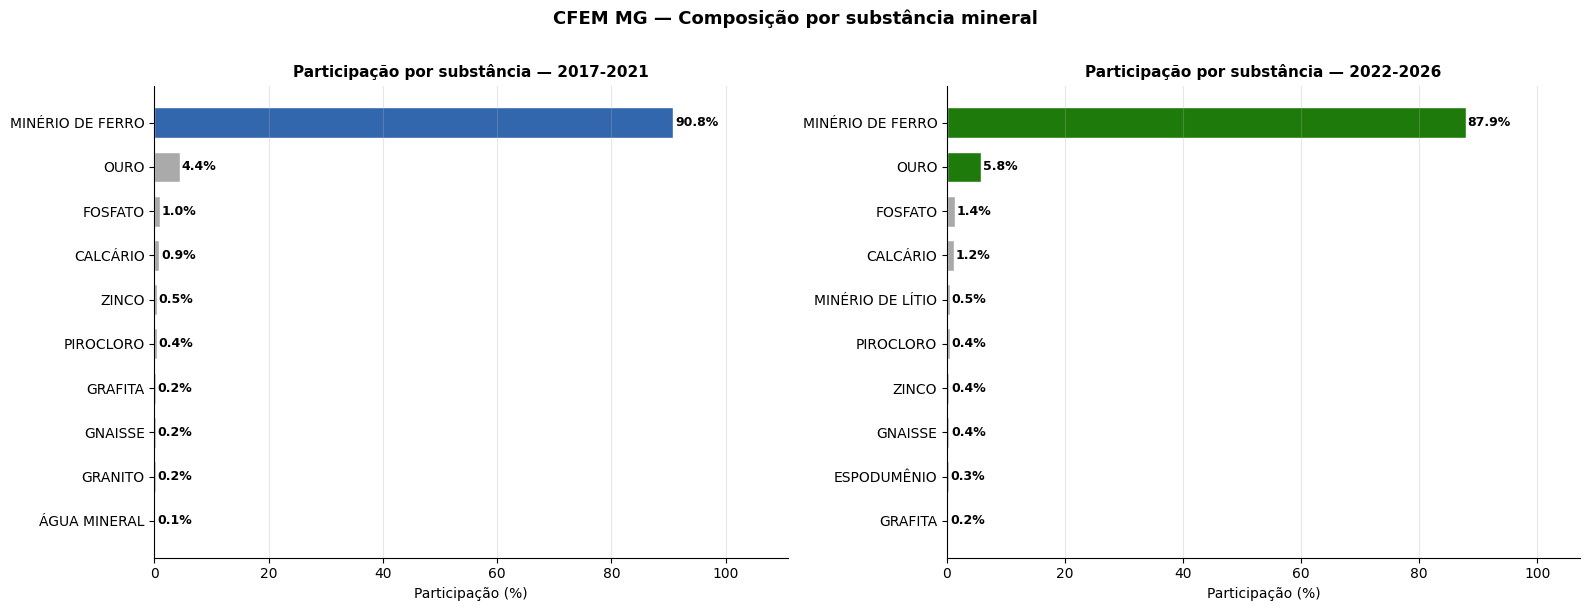

Gráfico salvo no Drive ✅


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, df_s, periodo, cor_base in [
    (axes[0], s_1721, '2017-2021', '#3266ad'),
    (axes[1], s_2226, '2022-2026', '#1E7A0A'),
]:
    df_r = df_s.iloc[::-1]
    cores = [cor_base if p > 5 else '#AAAAAA' for p in df_r['Part%']]
    bars  = ax.barh(df_r['Substância'], df_r['Part%'],
                    color=cores, edgecolor='white', height=0.7)

    for bar, val in zip(bars, df_r['Part%']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')

    ax.set_title(f'Participação por substância — {periodo}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Participação (%)', fontsize=10)
    ax.set_xlim(0, df_r['Part%'].max() * 1.22)
    ax.grid(axis='x', alpha=0.3); ax.spines[['top','right']].set_visible(False)

plt.suptitle('CFEM MG — Composição por substância mineral', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{PASTA}/graficos/nb5_substancias_participacao.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo no Drive ✅")


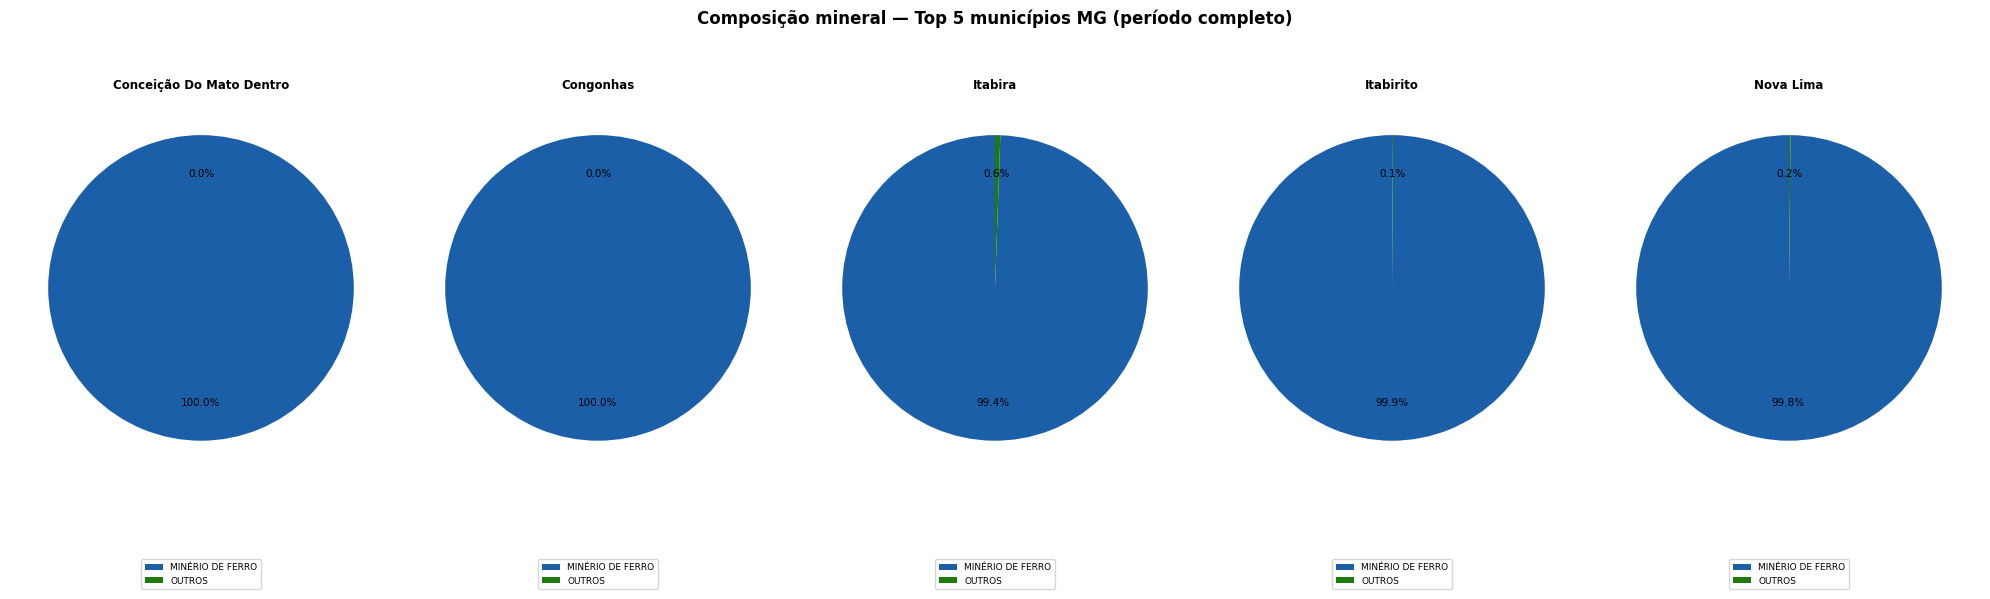

Gráfico salvo no Drive ✅


In [ ]:
top5 = (df_mg.groupby('Município')['ValorRecolhido'].sum()
             .sort_values(ascending=False).head(5).index.tolist())

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
cores_pie = ['#1A5FA8','#1E7A0A','#C0392B','#8C5A00','#5F5E5A','#AAAAAA']

for ax, mun in zip(axes, top5):
    comp  = (df_mg[df_mg['Município']==mun]
             .groupby('SubstPad')['ValorRecolhido'].sum()
             .sort_values(ascending=False))
    total = comp.sum()
    # Agrupar substâncias com < 3% em "Outros"
    mask   = comp / total >= 0.03
    outros = comp[~mask].sum()
    comp   = comp[mask].copy()
    if outros > 0: comp['OUTROS'] = outros

    wedges, _, autotexts = ax.pie(
        comp.values, autopct='%1.1f%%',
        colors=cores_pie[:len(comp)], startangle=90,
        pctdistance=0.75, textprops={'fontsize':7.5})
    for at in autotexts: at.set_fontsize(7.5)

    ax.set_title(mun.title(), fontsize=8.5, fontweight='bold', pad=6)
    ax.legend(comp.index, fontsize=6.5, loc='lower center',
              bbox_to_anchor=(0.5, -0.3), ncol=1)

plt.suptitle('Composição mineral — Top 5 municípios MG (período completo)',
             fontsize=12, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(f"{PASTA}/graficos/nb5_composicao_top5.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo no Drive ✅")


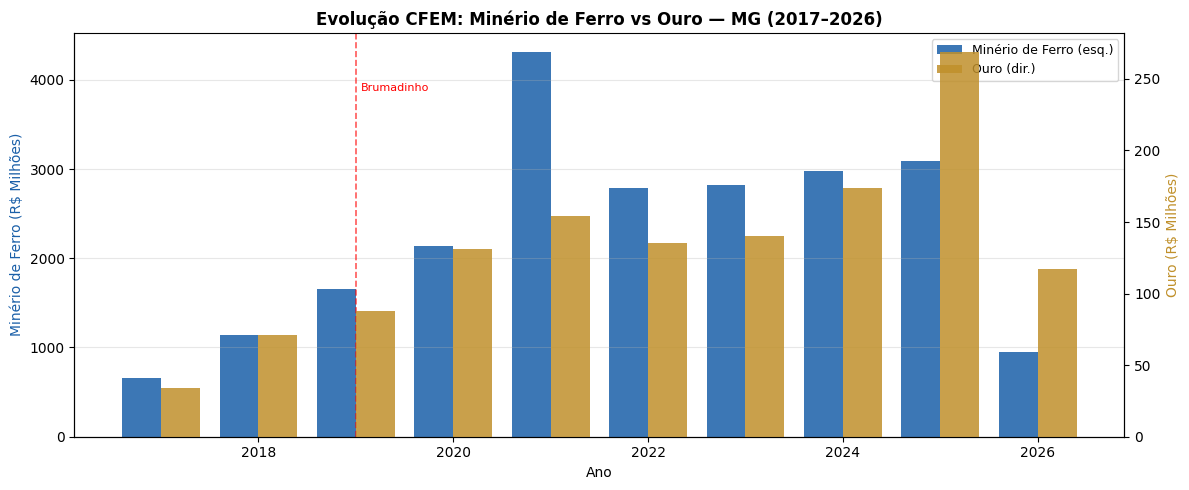

Gráfico salvo no Drive ✅


In [ ]:
foco = ['MINÉRIO DE FERRO','OURO']
pivot_s = (df_mg[df_mg['SubstPad'].isin(foco)]
           .groupby(['Ano','SubstPad'])['ValorRecolhido'].sum()
           .unstack('SubstPad').fillna(0) / 1e6)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

if 'MINÉRIO DE FERRO' in pivot_s.columns:
    ax1.bar(pivot_s.index - 0.2, pivot_s['MINÉRIO DE FERRO'],
            width=0.4, color='#1A5FA8', alpha=0.85, label='Minério de Ferro (esq.)')
if 'OURO' in pivot_s.columns:
    ax2.bar(pivot_s.index + 0.2, pivot_s['OURO'],
            width=0.4, color='#C0902B', alpha=0.85, label='Ouro (dir.)')

ax1.axvline(2019, color='red', linestyle='--', linewidth=1.2, alpha=0.65)
ax1.text(2019.05, pivot_s.get('MINÉRIO DE FERRO', pd.Series([0])).max()*0.9,
         'Brumadinho', color='red', fontsize=8)

ax1.set_title('Evolução CFEM: Minério de Ferro vs Ouro — MG (2017–2026)',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('Minério de Ferro (R$ Milhões)', fontsize=10, color='#1A5FA8')
ax2.set_ylabel('Ouro (R$ Milhões)',             fontsize=10, color='#C0902B')
ax1.set_xlabel('Ano', fontsize=10)

h1,l1 = ax1.get_legend_handles_labels()
h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, fontsize=9)
ax1.grid(axis='y', alpha=0.3); ax1.spines[['top']].set_visible(False)
plt.tight_layout()
plt.savefig(f"{PASTA}/graficos/nb5_ferro_vs_ouro.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo no Drive ✅")


In [ ]:
total  = df_mg['ValorRecolhido'].sum()
ferro  = df_mg[df_mg['SubstPad']=='MINÉRIO DE FERRO']['ValorRecolhido'].sum()
ouro   = df_mg[df_mg['SubstPad']=='OURO']['ValorRecolhido'].sum()
resto  = total - ferro - ouro

print("=" * 55)
print("RESUMO — CFEM MG por Substância (2017–2026)")
print("=" * 55)
print(f"Total arrecadado (MG)  : R$ {total/1e9:.2f} bilhões")
print(f"Minério de ferro       : R$ {ferro/1e9:.2f} bi  ({ferro/total*100:.1f}%)")
print(f"Ouro                   : R$ {ouro/1e9:.2f}  bi  ({ouro/total*100:.1f}%)")
print(f"Demais substâncias     : R$ {resto/1e9:.2f} bi  ({resto/total*100:.1f}%)")
print()
print(f"→ {ferro/total*100:.0f}% de toda a arrecadação CFEM de MG vem do minério de ferro.")
print(f"→ Minas Gerais é essencialmente um estado do ferro.")


RESUMO — CFEM MG por Substância (2017–2026)
Total arrecadado (MG)  : R$ 25.25 bilhões
Minério de ferro       : R$ 22.51 bi  (89.2%)
Ouro                   : R$ 1.31  bi  (5.2%)
Demais substâncias     : R$ 1.42 bi  (5.6%)

→ 89% de toda a arrecadação CFEM de MG vem do minério de ferro.
→ Minas Gerais é essencialmente um estado do ferro.
